In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("books.csv")
df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [3]:
# checking for missing value
print("Total Records:", len(df))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate UPCs:")
print(df["UPC"].duplicated().sum())

Total Records: 100

Missing Values:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

Duplicate UPCs:
0


In [32]:
# removing extra spaces 
df["title"] = df["title"].str.strip()
df["category"] = df["category"].str.strip()
df["availability"] = df["availability"].str.strip()
df["product_description"] = df["product_description"].str.strip()

df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,0,230,High,0.04,No
1,Libertarianism for Beginners,Politics,51.33,2,In stock,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,0,195,High,0.04,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,0,283,Medium,0.03,No
3,Olio,Poetry,23.88,1,In stock,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,0,249,Medium,0.04,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,0,163,High,0.05,No


In [5]:
#removing duplicates
df = df.drop_duplicates(subset="UPC")
print("Total Records after removing duplicates:", len(df))

Total Records after removing duplicates: 100


In [6]:
# converting price to numeric values
df["price"] = df["price"].str.replace("£","", regex=False)
df["price"] = df["price"].astype(float)
df["price"].head()

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: price, dtype: float64

In [35]:
rating_map = {

    "One":1,

    "Two":2,

    "Three":3,

    "Four":4,

    "Five":5

}

df["rating"] = df["rating"].map(rating_map)

df[["rating"]].head()

,rating
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [36]:
df["stock_count"] = df["availability"].str.extract(r'(\d+)')
df["stock_count"] = df["stock_count"].fillna(0)
df["stock_count"] = df["stock_count"].astype(int)
df[["availability","stock_count"]].head()

C:\Users\diash\AppData\Local\Temp\ipykernel_24624\315335434.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,availability,stock_count
0,In stock,0
1,In stock,0
2,In stock,0
3,In stock,0
4,In stock,0


In [37]:
df["description_word_count"] = df["product_description"].apply(lambda x: len(str(x).split()))
df[["description_word_count"]].head()

,description_word_count
0,230
1,195
2,283
3,249
4,163


In [10]:
df["price_band"] = pd.cut(

    df["price"],

    bins=[0,20,40,100],

    labels=["Low","Medium","High"]

)

df[["price","price_band"]].head()

,price,price_band
0,45.17,High
1,51.33,High
2,37.59,Medium
3,23.88,Medium
4,57.25,High


In [11]:
df["affordability_score"] = round(df["rating"] / df["price"],2)

df[["price","rating","affordability_score"]].head()

,price,rating,affordability_score
0,45.17,2,0.04
1,51.33,2,0.04
2,37.59,1,0.03
3,23.88,1,0.04
4,57.25,3,0.05


In [12]:
df["recommended"] = np.where(

    (df["rating"]>=4) & (df["price"]<35),

    "Yes",

    "No"

)

df[["title","recommended"]].head()

,title,recommended
0,It's Only the Himalayas,No
1,Libertarianism for Beginners,No
2,Mesaerion: The Best Science Fiction Stories 18...,No
3,Olio,No
4,Our Band Could Be Your Life: Scenes from the A...,No


In [13]:
df.to_csv("cleaned_books.csv",index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [14]:
pip install wordcloud

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Better looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
# Load cleaned dataset
df = pd.read_csv("cleaned_books.csv")
df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,0,230,High,0.04,No
1,Libertarianism for Beginners,Politics,51.33,2,In stock,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,0,195,High,0.04,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,0,283,Medium,0.03,No
3,Olio,Poetry,23.88,1,In stock,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,0,249,Medium,0.04,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,0,163,High,0.05,No


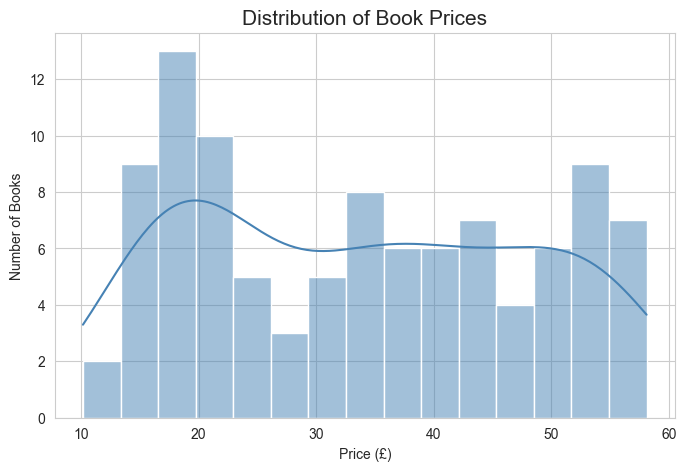

In [19]:
# Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=15, kde=True, color="steelblue")

plt.title("Distribution of Book Prices", fontsize=15)
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [20]:
#insight
"""  here we can see that the price distribution of the books is distributed 
farly .Most of the books are between the range 20-40,very less are too cheap and 
too expensive """

'here we can see that the price distribution of the books is distributed \nfarly .Most of the books are between the range 20-40,very less are too cheap and \ntoo expensive'

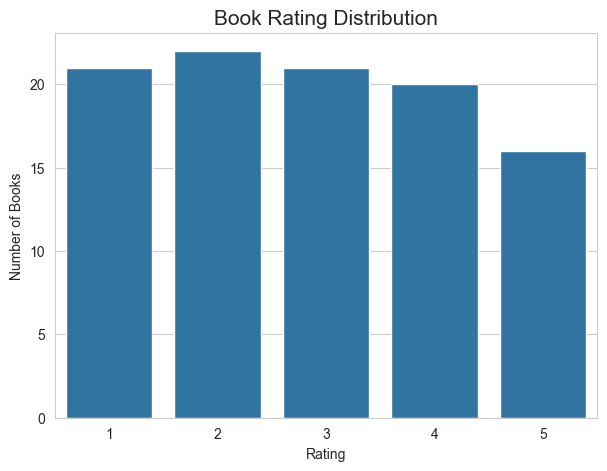

In [21]:
#Rating Distribution

plt.figure(figsize=(7,5))

sns.countplot(x="rating", data=df)

plt.title("Book Rating Distribution", fontsize=15)
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

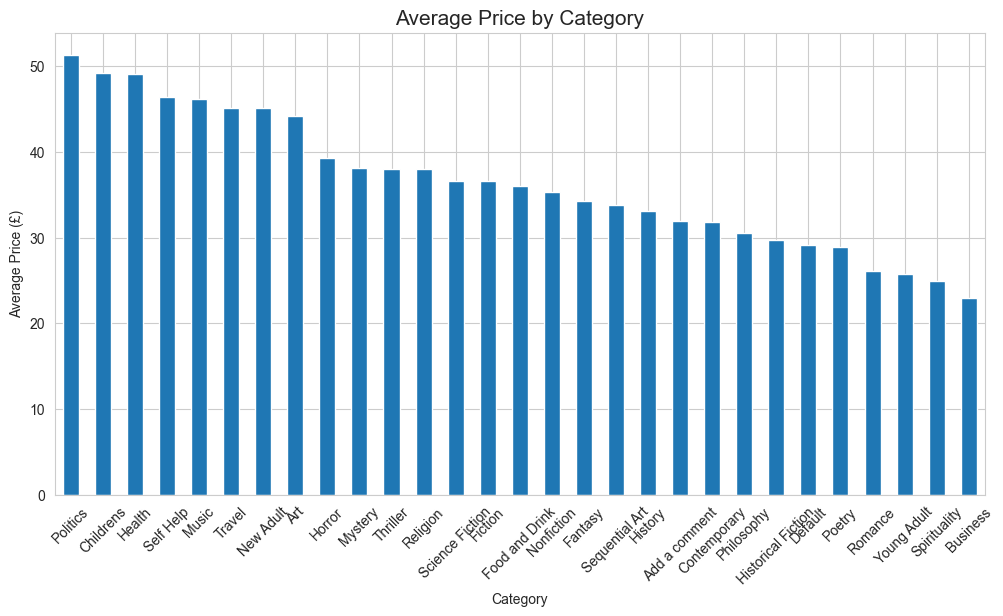

In [22]:
#Average price by category
avg_price = (
    df.groupby("category")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

avg_price.plot(kind="bar")

plt.title("Average Price by Category", fontsize=15)
plt.xlabel("Category")
plt.ylabel("Average Price (£)")

plt.xticks(rotation=45)

plt.show()

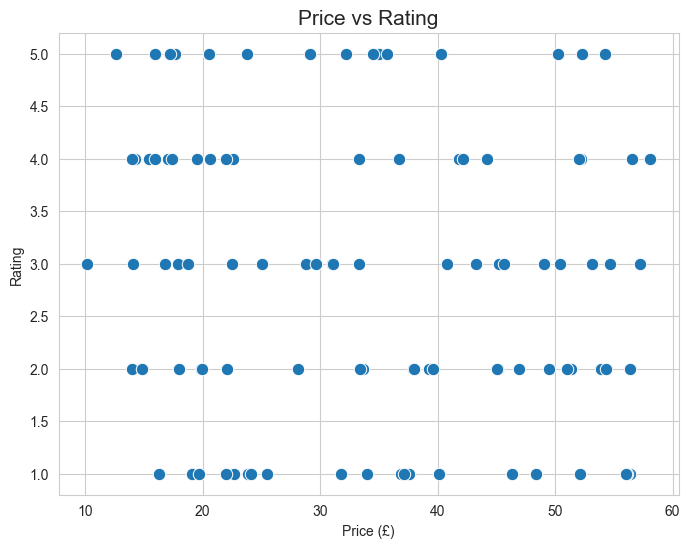

In [23]:
#Relationship between price and rating
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="price",
    y="rating",
    s=80
)

plt.title("Price vs Rating", fontsize=15)
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

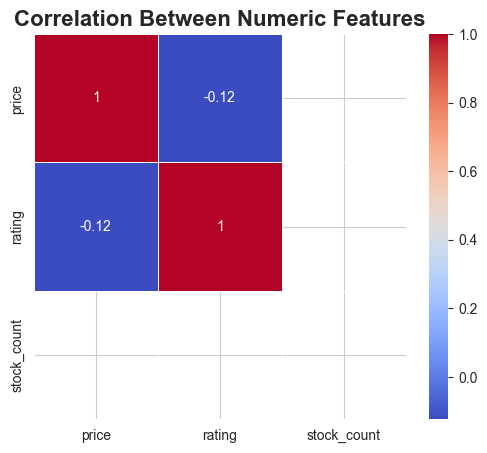

In [26]:
plt.figure(figsize=(6,5))

corr = df[["price", "rating", "stock_count"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Features", fontsize=16, fontweight="bold")

plt.show()

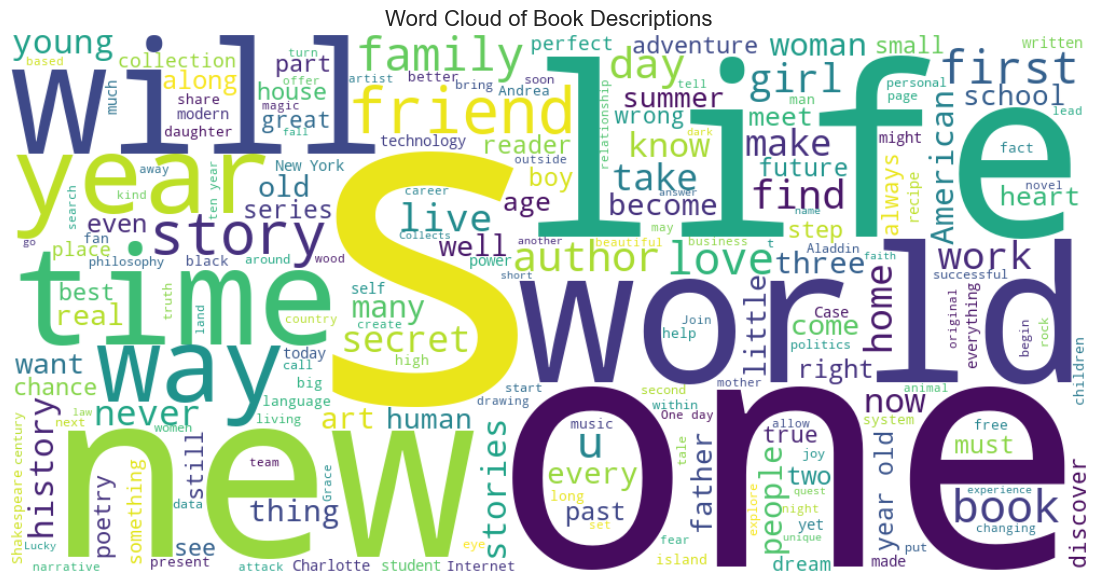

In [28]:
#word cloud

text = " ".join(df["product_description"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Book Descriptions", fontsize=16)

plt.show()

In [29]:
#summary statistics
print("Summary Statistics")
df.describe(include="all")

Summary Statistics


,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,recommended
count,100,100,100.000000,100.000000,100,100,100,100.0,100,100.0,100.0000,100,100.00000,100
unique,100,29,NaN,NaN,1,100,100,NaN,100,NaN,NaN,3,NaN,2
top,It's Only the Himalayas,Sequential Art,NaN,NaN,In stock,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,NaN,https://books.toscrape.com/catalogue/its-only-...,NaN,NaN,High,NaN,No
freq,1,16,NaN,NaN,100,1,1,NaN,1,NaN,NaN,37,NaN,79
mean,NaN,NaN,33.857700,2.880000,NaN,NaN,NaN,0.0,NaN,0.0,225.3800,NaN,0.10830,NaN
std,NaN,NaN,14.198283,1.380089,NaN,NaN,NaN,0.0,NaN,0.0,107.7645,NaN,0.08351,NaN
min,NaN,NaN,10.160000,1.000000,NaN,NaN,NaN,0.0,NaN,0.0,36.0000,NaN,0.02000,NaN
25%,NaN,NaN,19.897500,2.000000,NaN,NaN,NaN,0.0,NaN,0.0,163.7500,NaN,0.04750,NaN
50%,NaN,NaN,33.500000,3.000000,NaN,NaN,NaN,0.0,NaN,0.0,213.0000,NaN,0.08500,NaN
75%,NaN,NaN,45.795000,4.000000,NaN,NaN,NaN,0.0,NaN,0.0,276.5000,NaN,0.14000,NaN


In [30]:
# highly rated books
top_books = (
    df.sort_values(
        by=["rating","price"],
        ascending=[False,True]
    )
    [["title","category","rating","price"]]
)

top_books.head(10)

,title,category,rating,price
97,The Third Wave: An Entrepreneur’s Vision of th...,Business,5,12.61
21,Sophie's World,Philosophy,5,15.94
37,Thirst,Fiction,5,17.27
7,Set Me Free,Young Adult,5,17.46
25,The Four Agreements: A Practical Guide to Pers...,Spirituality,5,17.66
62,The Inefficiency Assassin: Time Management Tac...,Default,5,20.59
23,The Elephant Tree,Thriller,5,23.82
84,Call the Nurse: True Stories of a Country Nurs...,Nonfiction,5,29.14
55,The Activist's Tao Te Ching: Ancient Advice fo...,Spirituality,5,32.24
31,Black Dust,Romance,5,34.53


In [31]:
#category -wise summary
summary = df.groupby("category").agg({

    "price":"mean",

    "rating":"mean",

    "stock_count":"sum"

}).round(2)

summary

,price,rating,stock_count
category,,,
Add a comment,31.96,2.25,0
Art,44.18,4.00,0
Business,22.98,4.50,0
Childrens,49.22,1.67,0
Contemporary,31.77,1.00,0
Default,29.11,2.90,0
Fantasy,34.32,2.60,0
Fiction,36.56,4.67,0
Food and Drink,35.98,2.00,0
